In [2]:
import importlib
import linear_model
import mlp_model

importlib.reload(linear_model)
importlib.reload(mlp_model)


<module 'mlp_model' from '/home/vectra/code/efrei/projet_Maths_pour_ML/mlp_model.py'>

In [3]:
print('Fonctions disponibles dans linear_model :')
print(dir(linear_model))

print('\nFonctions disponibles dans mlp_model :')
print(dir(mlp_model))


Fonctions disponibles dans linear_model :
['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'accuracy', 'compute_gradients', 'compute_scores', 'cross_entropy_loss', 'initialize_parameters', 'np', 'predict', 'softmax', 'train_linear_model', 'update_parameters']

Fonctions disponibles dans mlp_model :
['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'accuracy', 'backward_mlp', 'cross_entropy_loss', 'forward_mlp', 'get_activation_functions', 'initialize_mlp_parameters', 'normalize_hidden_dims', 'np', 'predict_mlp', 'predict_proba_mlp', 'relu', 'relu_derivative', 'sigmoid', 'sigmoid_derivative', 'softmax', 'tanh', 'tanh_derivative', 'train_mlp_model', 'update_mlp_parameters']


## References :
- (initialisation aleatoire des poids) https://cs231n.github.io/neural-networks-2/
- (scikitlearn) (eviter les erreurs numeriques du type ln(0)) : https://scikit-learn.org/stable/modules/generated/sklearn.metrics.log_loss.html
- (derivee de softmax) : https://mldawn.com/the-derivative-of-softmax-function-w-r-t-z/
- (MNIST Keras dataset) https://keras.io/api/datasets/mnist/


# 1) Import de MNIST et préparation des données

I0000 00:00:1777393224.032223   37735 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777393224.032953   37735 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777393224.072598   37735 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777393227.883107   37735 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
=== Dimensions initiales ===
X_train : (60000, 28, 28)
y_train : (60000,)
X_test  : (10000, 28, 28)
y_test  : (10000,)

=== Valeurs des pixels avant normalisation ===
Min train : 0 | Max train : 255
Min test  : 0 | Max test  : 255


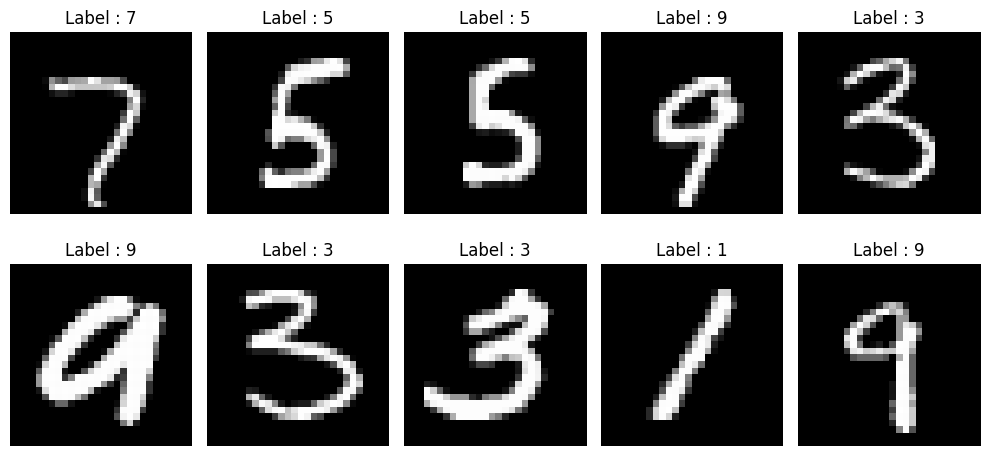


=== Valeurs des pixels après normalisation ===
Min train : 0.0 | Max train : 1.0
Min test  : 0.0 | Max test  : 1.0

=== Dimensions après aplatissement ===
X_train_flat : (60000, 784)
X_test_flat  : (10000, 784)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# =========================
# 1) Chargement du dataset
# =========================
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print('=== Dimensions initiales ===')
print('X_train :', X_train.shape)
print('y_train :', y_train.shape)
print('X_test  :', X_test.shape)
print('y_test  :', y_test.shape)

print('\n=== Valeurs des pixels avant normalisation ===')
print('Min train :', X_train.min(), '| Max train :', X_train.max())
print('Min test  :', X_test.min(), '| Max test  :', X_test.max())

assert X_train.shape[1:] == (28, 28)
assert X_test.shape[1:] == (28, 28)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
indices = np.random.choice(len(X_train), 10, replace=False)

for ax, idx in zip(axes.flat, indices):
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(f'Label : {y_train[idx]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

# =========================
# 2) Normalisation + aplatissement
# =========================
X_train = X_train.astype(np.float64) / 255.0
X_test = X_test.astype(np.float64) / 255.0

X_train_flat = X_train.reshape(X_train.shape[0], 28 * 28)
X_test_flat = X_test.reshape(X_test.shape[0], 28 * 28)

print('\n=== Valeurs des pixels après normalisation ===')
print('Min train :', X_train.min(), '| Max train :', X_train.max())
print('Min test  :', X_test.min(), '| Max test  :', X_test.max())

print('\n=== Dimensions après aplatissement ===')
print('X_train_flat :', X_train_flat.shape)
print('X_test_flat  :', X_test_flat.shape)


# 2) One-Hot encoding

In [6]:
from utils import one_hot_encode

Y_train = one_hot_encode(y_train, num_classes=10)
Y_test = one_hot_encode(y_test, num_classes=10)

print('y_train shape :', y_train.shape)
print('Y_train shape :', Y_train.shape)

print('\nExemples :')
for i in range(5):
    print(f'label brut = {y_train[i]} -> one-hot = {Y_train[i]}')


y_train shape : (60000,)
Y_train shape : (60000, 10)

Exemples :
label brut = 5 -> one-hot = [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
label brut = 0 -> one-hot = [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
label brut = 4 -> one-hot = [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
label brut = 1 -> one-hot = [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
label brut = 9 -> one-hot = [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


# 3) Configuration du test comparatif

In [14]:
# Pour des tests rapides dans un notebook, on peut travailler sur un sous-ensemble.
USE_SUBSET = True
TRAIN_SIZE = 12000
TEST_SIZE = 3000

LINEAR_EPOCHS = 100
MLP_1_EPOCHS = 100
MLP_2_EPOCHS = 100

LINEAR_LR = 0.1
MLP_LR = 0.05

HIDDEN_DIM_1 = 128
HIDDEN_DIMS_2 = [128, 64]
ACTIVATION = 'relu'
SEED = 0

if USE_SUBSET:
    X_train_run = X_train_flat[:TRAIN_SIZE]
    Y_train_run = Y_train[:TRAIN_SIZE]
    y_train_run = y_train[:TRAIN_SIZE]
    X_test_run = X_test_flat[:TEST_SIZE]
    Y_test_run = Y_test[:TEST_SIZE]
    y_test_run = y_test[:TEST_SIZE]
else:
    X_train_run = X_train_flat
    Y_train_run = Y_train
    y_train_run = y_train
    X_test_run = X_test_flat
    Y_test_run = Y_test
    y_test_run = y_test

print('USE_SUBSET =', USE_SUBSET)
print('X_train_run :', X_train_run.shape)
print('X_test_run  :', X_test_run.shape)
print('LINEAR_EPOCHS =', LINEAR_EPOCHS)
print('MLP_1_EPOCHS =', MLP_1_EPOCHS)
print('MLP_2_EPOCHS =', MLP_2_EPOCHS)


USE_SUBSET = True
X_train_run : (12000, 784)
X_test_run  : (3000, 784)
LINEAR_EPOCHS = 100
MLP_1_EPOCHS = 100
MLP_2_EPOCHS = 100


# 4) Vérification rapide du softmax

In [15]:
from linear_model import softmax

scores_test = np.array([[1.0, 2.0, 3.0], [0.5, 0.1, -1.2]])
probs_test = softmax(scores_test)

print('Probabilités :')
print(probs_test)
print('\nSomme de chaque ligne :')
print(np.sum(probs_test, axis=1))


Probabilités :
[[0.09003057 0.24472847 0.66524096]
 [0.53966437 0.36174784 0.09858779]]

Somme de chaque ligne :
[1. 1.]


# 5) Entraînement du modèle linéaire

In [16]:
from linear_model import train_linear_model, predict, accuracy

A, b, linear_loss_history = train_linear_model(
    X_train_run,
    Y_train_run,
    input_dim=784,
    num_classes=10,
    learning_rate=LINEAR_LR,
    epochs=LINEAR_EPOCHS
)

y_pred_train_linear = predict(X_train_run, A, b)
y_pred_test_linear = predict(X_test_run, A, b)

acc_train_linear = accuracy(y_train_run, y_pred_train_linear)
acc_test_linear = accuracy(y_test_run, y_pred_test_linear)

print('Première log loss :', linear_loss_history[0])
print('Dernière log loss :', linear_loss_history[-1])
print('Accuracy train (linéaire) :', acc_train_linear)
print('Accuracy test  (linéaire) :', acc_test_linear)


Première log loss : 2.2978832883367417
Dernière log loss : 0.5862184034894199
Accuracy train (linéaire) : 0.8688333333333333
Accuracy test  (linéaire) : 0.8286666666666667


# 6) Entraînement du MLP avec une couche cachée (H = 1)

In [17]:
from mlp_model import train_mlp_model, predict_mlp, accuracy as mlp_accuracy

params_mlp_1, mlp_1_loss_history = train_mlp_model(
    X_train_run,
    Y_train_run,
    hidden_dims=HIDDEN_DIM_1,
    learning_rate=MLP_LR,
    epochs=MLP_1_EPOCHS,
    activation=ACTIVATION,
    seed=SEED,
    verbose=True
)

y_pred_train_mlp_1 = predict_mlp(X_train_run, params_mlp_1, activation=ACTIVATION)
y_pred_test_mlp_1 = predict_mlp(X_test_run, params_mlp_1, activation=ACTIVATION)

acc_train_mlp_1 = mlp_accuracy(y_train_run, y_pred_train_mlp_1)
acc_test_mlp_1 = mlp_accuracy(y_test_run, y_pred_test_mlp_1)

print('Première log loss :', mlp_1_loss_history[0])
print('Dernière log loss :', mlp_1_loss_history[-1])
print('Accuracy train (MLP H=1) :', acc_train_mlp_1)
print('Accuracy test  (MLP H=1) :', acc_test_mlp_1)


Epoch 1/100 - loss : 2.341050
Epoch 11/100 - loss : 2.031520
Epoch 21/100 - loss : 1.767797
Epoch 31/100 - loss : 1.523769
Epoch 41/100 - loss : 1.316368
Epoch 51/100 - loss : 1.150348
Epoch 61/100 - loss : 1.020451
Epoch 71/100 - loss : 0.919033
Epoch 81/100 - loss : 0.839067
Epoch 91/100 - loss : 0.775012
Epoch 100/100 - loss : 0.727652
Première log loss : 2.341050108400222
Dernière log loss : 0.7276524622018323
Accuracy train (MLP H=1) : 0.83925
Accuracy test  (MLP H=1) : 0.7906666666666666


# 7) Entraînement du MLP avec deux couches cachées (H = 2)

In [18]:
params_mlp_2, mlp_2_loss_history = train_mlp_model(
    X_train_run,
    Y_train_run,
    hidden_dims=HIDDEN_DIMS_2,
    learning_rate=MLP_LR,
    epochs=MLP_2_EPOCHS,
    activation=ACTIVATION,
    seed=SEED,
    verbose=True
)

y_pred_train_mlp_2 = predict_mlp(X_train_run, params_mlp_2, activation=ACTIVATION)
y_pred_test_mlp_2 = predict_mlp(X_test_run, params_mlp_2, activation=ACTIVATION)

acc_train_mlp_2 = mlp_accuracy(y_train_run, y_pred_train_mlp_2)
acc_test_mlp_2 = mlp_accuracy(y_test_run, y_pred_test_mlp_2)

print('Première log loss :', mlp_2_loss_history[0])
print('Dernière log loss :', mlp_2_loss_history[-1])
print('Accuracy train (MLP H=2) :', acc_train_mlp_2)
print('Accuracy test  (MLP H=2) :', acc_test_mlp_2)


Epoch 1/100 - loss : 2.291191
Epoch 11/100 - loss : 2.022280
Epoch 21/100 - loss : 1.736080
Epoch 31/100 - loss : 1.443083
Epoch 41/100 - loss : 1.179100
Epoch 51/100 - loss : 0.975161
Epoch 61/100 - loss : 0.829310
Epoch 71/100 - loss : 0.726198
Epoch 81/100 - loss : 0.651594
Epoch 91/100 - loss : 0.595917
Epoch 100/100 - loss : 0.556944
Première log loss : 2.2911909375382615
Dernière log loss : 0.5569436330740314
Accuracy train (MLP H=2) : 0.8658333333333333
Accuracy test  (MLP H=2) : 0.823


# 8) Comparatif des courbes de loss

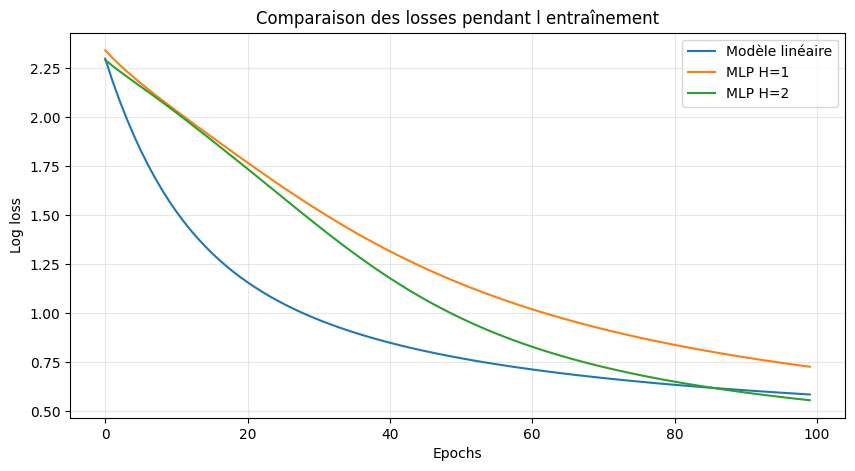

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(linear_loss_history, label='Modèle linéaire')
plt.plot(mlp_1_loss_history, label='MLP H=1')
plt.plot(mlp_2_loss_history, label='MLP H=2')
plt.xlabel('Epochs')
plt.ylabel('Log loss')
plt.title('Comparaison des losses pendant l entraînement')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# 9) Comparatif des performances train/test

In [20]:
results = [
    {
        'modèle': 'Linéaire',
        'hidden_dims': '-',
        'activation': '-',
        'epochs': LINEAR_EPOCHS,
        'acc_train': acc_train_linear,
        'acc_test': acc_test_linear,
        'loss_finale': linear_loss_history[-1],
    },
    {
        'modèle': 'MLP H=1',
        'hidden_dims': HIDDEN_DIM_1,
        'activation': ACTIVATION,
        'epochs': MLP_1_EPOCHS,
        'acc_train': acc_train_mlp_1,
        'acc_test': acc_test_mlp_1,
        'loss_finale': mlp_1_loss_history[-1],
    },
    {
        'modèle': 'MLP H=2',
        'hidden_dims': str(HIDDEN_DIMS_2),
        'activation': ACTIVATION,
        'epochs': MLP_2_EPOCHS,
        'acc_train': acc_train_mlp_2,
        'acc_test': acc_test_mlp_2,
        'loss_finale': mlp_2_loss_history[-1],
    },
]

try:
    import pandas as pd
    df_results = pd.DataFrame(results)
    display(df_results)
except Exception:
    for row in results:
        print(row)


{'modèle': 'Linéaire', 'hidden_dims': '-', 'activation': '-', 'epochs': 100, 'acc_train': np.float64(0.8688333333333333), 'acc_test': np.float64(0.8286666666666667), 'loss_finale': np.float64(0.5862184034894199)}
{'modèle': 'MLP H=1', 'hidden_dims': 128, 'activation': 'relu', 'epochs': 100, 'acc_train': np.float64(0.83925), 'acc_test': np.float64(0.7906666666666666), 'loss_finale': np.float64(0.7276524622018323)}
{'modèle': 'MLP H=2', 'hidden_dims': '[128, 64]', 'activation': 'relu', 'epochs': 100, 'acc_train': np.float64(0.8658333333333333), 'acc_test': np.float64(0.823), 'loss_finale': np.float64(0.5569436330740314)}


# 10) Visualisation de prédictions sur le jeu de test

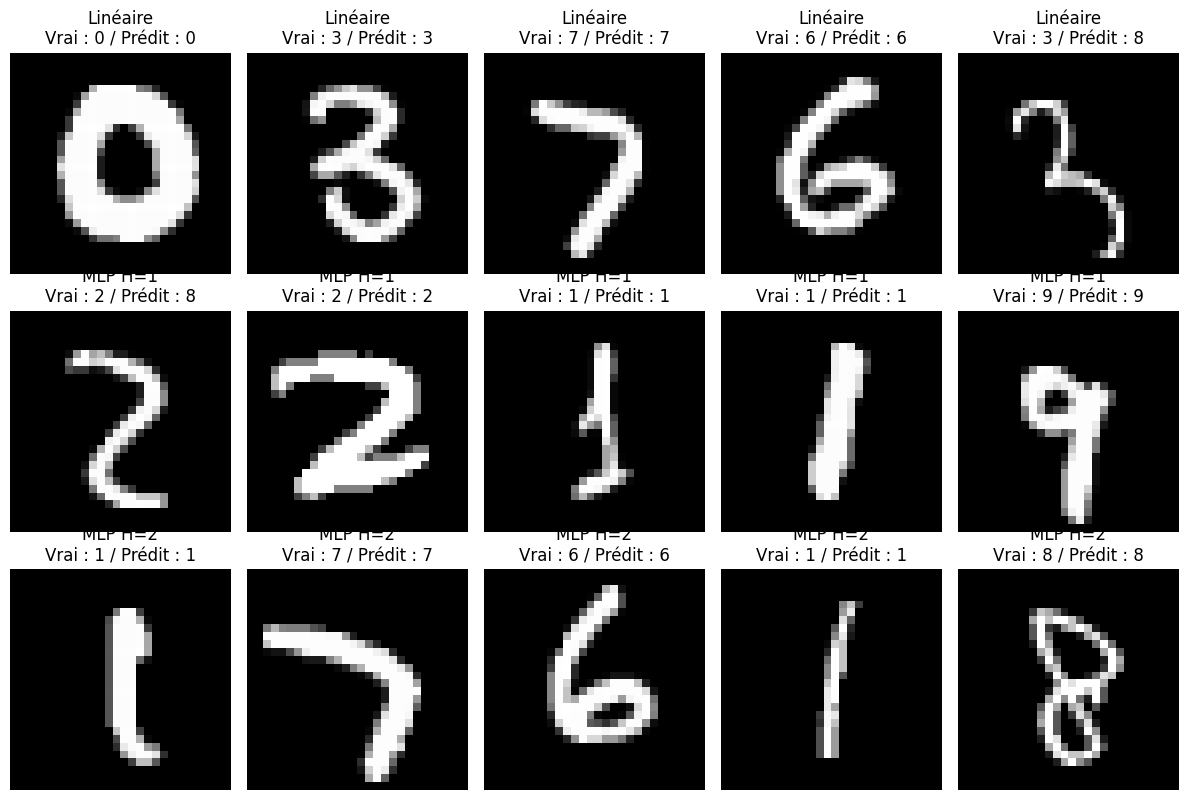

In [21]:
models_predictions = {
    'Linéaire': y_pred_test_linear,
    'MLP H=1': y_pred_test_mlp_1,
    'MLP H=2': y_pred_test_mlp_2,
}

fig, axes = plt.subplots(3, 5, figsize=(12, 8))
indices = np.random.choice(len(X_test_run), 15, replace=False)

for row_idx, (model_name, preds) in enumerate(models_predictions.items()):
    for col_idx in range(5):
        idx = indices[row_idx * 5 + col_idx]
        ax = axes[row_idx, col_idx]
        ax.imshow(X_test_run[idx].reshape(28, 28), cmap='gray')
        ax.set_title(f'{model_name}\nVrai : {y_test_run[idx]} / Prédit : {preds[idx]}')
        ax.axis('off')

plt.tight_layout()
plt.show()


# 11) Analyse rapide des erreurs du meilleur modèle

Meilleur modèle sur le test : Linéaire
Accuracy test associée : 0.8286666666666667
Nombre d erreurs sur le jeu de test utilisé : 514


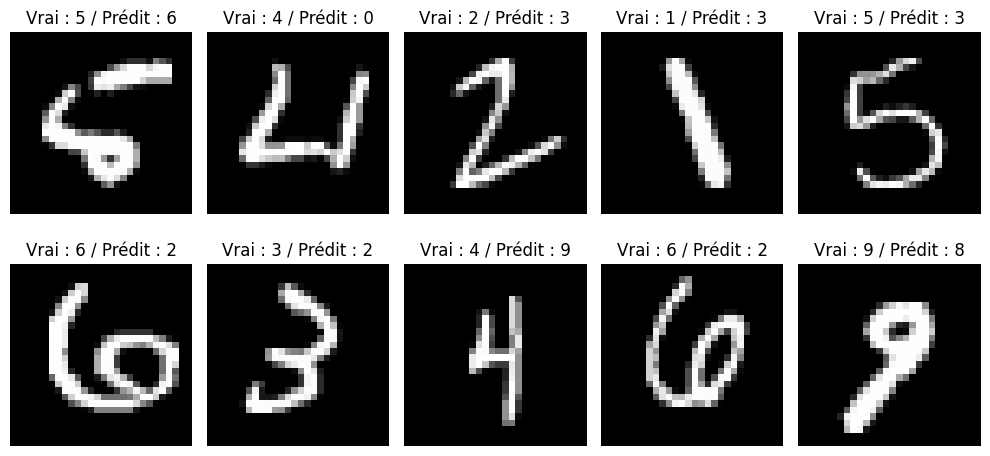

In [23]:
test_accuracies = {
    'Linéaire': acc_test_linear,
    'MLP H=1': acc_test_mlp_1,
    'MLP H=2': acc_test_mlp_2,
}

best_model_name = max(test_accuracies, key=test_accuracies.get)
print('Meilleur modèle sur le test :', best_model_name)
print('Accuracy test associée :', test_accuracies[best_model_name])

if best_model_name == 'Linéaire':
    best_preds = y_pred_test_linear
elif best_model_name == 'MLP H=1':
    best_preds = y_pred_test_mlp_1
else:
    best_preds = y_pred_test_mlp_2

errors = np.where(best_preds != y_test_run)[0]
print('Nombre d erreurs sur le jeu de test utilisé :', len(errors))

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for ax, idx in zip(axes.flat, errors[:10]):
    ax.imshow(X_test_run[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'Vrai : {y_test_run[idx]} / Prédit : {best_preds[idx]}')
    ax.axis('off')

plt.tight_layout()
plt.show()




Il faut ensuite comparer :
- le taux d'erreur train
- le taux d'erreur test
- la baisse de la loss
- les erreurs qualitatives sur les chiffres mal classés
